upload the datasets


In [1]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [12]:
import pandas as pd

df = pd.read_csv("data.csv", sep=";")

In [4]:
df.head()

,"Marital status;Application mode;Application order;Course;""Daytime/evening attendance\t"";Previous qualification;Previous qualification (grade);Nacionality;Mother's qualification;Father's qualification;Mother's occupation;Father's occupation;Admission grade;Displaced;Educational special needs;Debtor;Tuition fees up to date;Gender;Scholarship holder;Age at enrollment;International;Curricular units 1st sem (credited);Curricular units 1st sem (enrolled);Curricular units 1st sem (evaluations);Curricular units 1st sem (approved);Curricular units 1st sem (grade);Curricular units 1st sem (without evaluations);Curricular units 2nd sem (credited);Curricular units 2nd sem (enrolled);Curricular units 2nd sem (evaluations);Curricular units 2nd sem (approved);Curricular units 2nd sem (grade);Curricular units 2nd sem (without evaluations);Unemployment rate;Inflation rate;GDP;Target"
0,1;17;5;171;1;1;122.0;1;19;12;5;9;127.3;1;0;0;1...
1,1;15;1;9254;1;1;160.0;1;1;3;3;3;142.5;1;0;0;0;...
2,1;1;5;9070;1;1;122.0;1;37;37;9;9;124.8;1;0;0;0...
3,1;17;2;9773;1;1;122.0;1;38;37;5;3;119.6;1;0;0;...
4,2;39;1;8014;0;1;100.0;1;37;38;9;9;141.5;0;0;0;...


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [14]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [15]:
import pandas as pd
df = pd.read_csv("data.csv", sep=';')
df["Target"].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


Prepare the Target Variable

In [16]:
df["Target"] = df["Target"].map({
    "Dropout": 0,
    "Graduate": 1,
    "Enrolled": 2
})

In [10]:
df["Target"].value_counts()

,count
Target,
1,2209
0,1421
2,794


split features and target

In [19]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [20]:
print(X.shape)
print(y.shape)

(4424, 36)
(4424,)


Create Training and Test Sets

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (3539, 36)
Testing: (885, 36)


Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluate the Model

In [24]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7751412429378531


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78       284
           1       0.79      0.95      0.86       442
           2       0.57      0.36      0.44       159

    accuracy                           0.78       885
   macro avg       0.73      0.68      0.69       885
weighted avg       0.76      0.78      0.76       885



confusion matrix


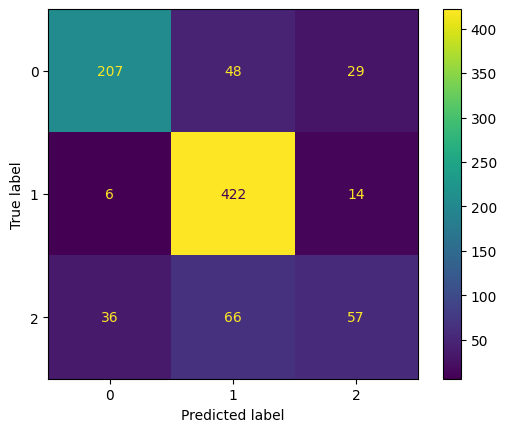

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

feature importance


In [27]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.145930
31,Curricular units 2nd sem (grade),0.115488
24,Curricular units 1st sem (approved),0.079076
25,Curricular units 1st sem (grade),0.061851
29,Curricular units 2nd sem (evaluations),0.041582
12,Admission grade,0.041281
16,Tuition fees up to date,0.041202
19,Age at enrollment,0.037976
23,Curricular units 1st sem (evaluations),0.036977
6,Previous qualification (grade),0.036818


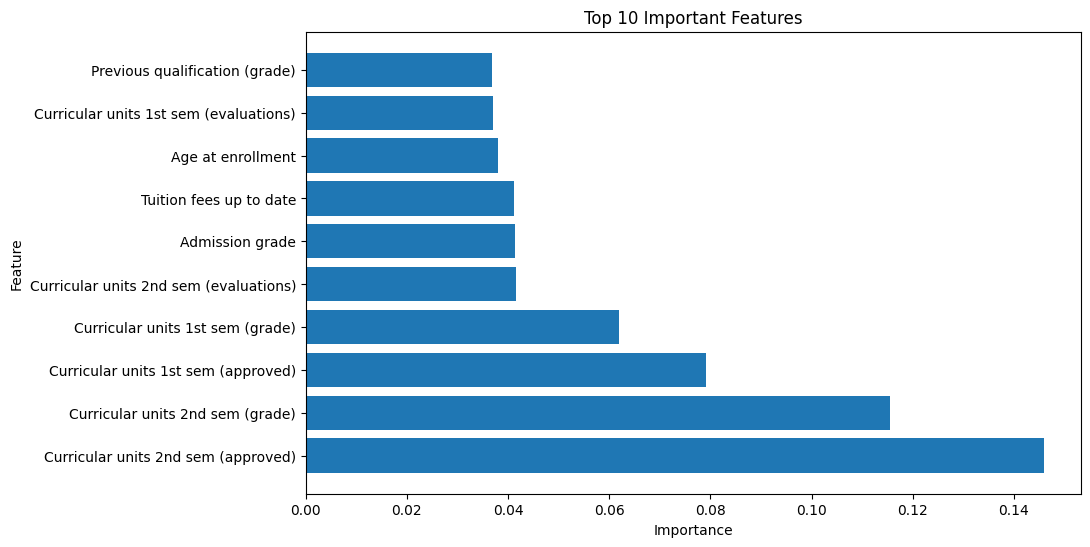

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.show()

Fairness Analysis

In [29]:
df['Gender'].value_counts()

,count
Gender,
0,2868
1,1556


In [30]:
print(df['Gender'].unique())

[1 0]


fairness analysis


In [31]:
male_df = df[df['Gender'] == 1]
female_df = df[df['Gender'] == 0]

print("Male Students:", len(male_df))
print("Female Students:", len(female_df))

Male Students: 1556
Female Students: 2868


In [32]:
from sklearn.metrics import accuracy_score

# Male
male_test = X_test[df.loc[X_test.index, 'Gender'] == 1]
male_y_test = y_test[df.loc[X_test.index, 'Gender'] == 1]

male_pred = model.predict(male_test)

male_accuracy = accuracy_score(
    male_y_test,
    male_pred
)

# Female
female_test = X_test[df.loc[X_test.index, 'Gender'] == 0]
female_y_test = y_test[df.loc[X_test.index, 'Gender'] == 0]

female_pred = model.predict(female_test)

female_accuracy = accuracy_score(
    female_y_test,
    female_pred
)

print("Male Accuracy:", male_accuracy)
print("Female Accuracy:", female_accuracy)

Male Accuracy: 0.7358490566037735
Female Accuracy: 0.7971781305114638


In [33]:
import joblib

joblib.dump(model, "dropout_model.pkl")

['dropout_model.pkl']

In [34]:
import os

os.listdir()

['.config', 'data.csv', 'dropout_model.pkl', 'sample_data']

In [37]:
from google.colab import files

files.download("dropout_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

accuracy


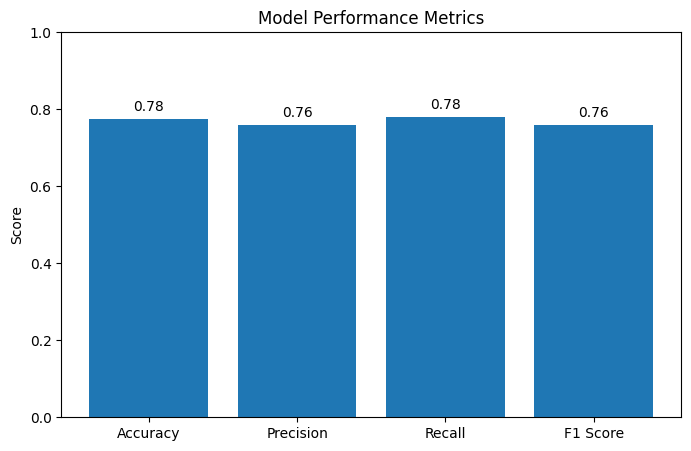

In [38]:
import matplotlib.pyplot as plt

metrics = {
    'Accuracy': 0.775,
    'Precision': 0.76,
    'Recall': 0.78,
    'F1 Score': 0.76
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Performance Metrics")

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, str(round(v,2)), ha='center')

plt.show()

In [ ]:
Class-wise F1 Score Graph

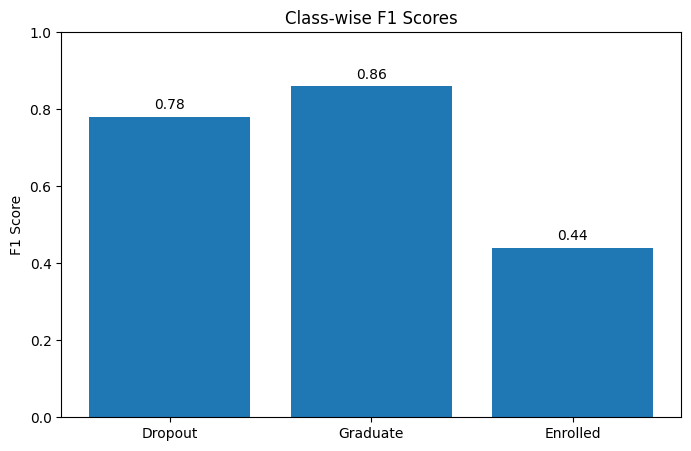

In [39]:
import matplotlib.pyplot as plt

classes = ['Dropout', 'Graduate', 'Enrolled']

f1_scores = [0.78, 0.86, 0.44]

plt.figure(figsize=(8,5))

plt.bar(classes, f1_scores)

plt.ylim(0,1)

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, str(v), ha='center')

plt.show()

In [42]:
plt.savefig("performance_metrics.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [43]:
plt.savefig("classwise_f1.png")
plt.show()

<Figure size 640x480 with 0 Axes>